# 01 — Exploratory Data Analysis
### AI-Powered Resume Screening & Candidate Role Recommendation
---
**Instructions:**
- Place `cleaned_resume_data.csv`, `cleaned_jobs_data.csv`, and `skills_list.csv` inside the `data/` folder.
- Run this notebook first. It saves `data/processed_resume.csv` and `data/processed_jobs.csv` for use by the next notebook.


In [1]:
import os, ast, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

for folder in ['data', 'plots', 'models', 'outputs']:
    os.makedirs(folder, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")


Libraries loaded.


## 1. Load Datasets

In [2]:
resume_df = pd.read_csv('data/cleaned_resume_data.csv')
skills_df = pd.read_csv('data/skills_list.csv')
jobs_df   = pd.read_csv('data/cleaned_jobs_data.csv')

print("Resume shape :", resume_df.shape)
print("Jobs shape   :", jobs_df.shape)
print("Skills shape :", skills_df.shape)


Resume shape : (10000, 13)
Jobs shape   : (15885, 7)
Skills shape : (793, 1)


## 2. Data Inspection

In [3]:
print("=== Resume Columns ===")
print(resume_df.dtypes)
print("\n=== Missing Values (Resume) ===")
print(resume_df.isnull().sum())


=== Resume Columns ===
Resume ID             str
Resume Text           str
Education             str
Experience Years    int64
Skills                str
Job Role              str
Category              str
clean_text            str
extracted_skills      str
skill_count         int64
category_encoded    int64
job_role_encoded    int64
education_level     int64
dtype: object

=== Missing Values (Resume) ===
Resume ID           0
Resume Text         0
Education           0
Experience Years    0
Skills              0
Job Role            0
Category            0
clean_text          0
extracted_skills    0
skill_count         0
category_encoded    0
job_role_encoded    0
education_level     0
dtype: int64


In [4]:
print("=== Jobs Columns ===")
print(jobs_df.dtypes)
print("\n=== Missing Values (Jobs) ===")
print(jobs_df.isnull().sum())


=== Jobs Columns ===
job_id                        int64
title                           str
description                     str
formatted_experience_level      str
location                        str
formatted_work_type             str
clean_description               str
dtype: object

=== Missing Values (Jobs) ===
job_id                           0
title                            0
description                      0
formatted_experience_level    4901
location                         0
formatted_work_type              0
clean_description                2
dtype: int64


## 3. Preprocessing & Cleaning

In [5]:
# ── Resume ──────────────────────────────────────────────────────────────────
before = resume_df.shape[0]
resume_df = resume_df.drop_duplicates().reset_index(drop=True)
print(f"Resume duplicates removed: {before - resume_df.shape[0]}")

# Parse extracted_skills from string to list
resume_df['extracted_skills'] = resume_df['extracted_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
resume_df['skill_count'] = resume_df['extracted_skills'].apply(len)

# ── Jobs ─────────────────────────────────────────────────────────────────────
before_j = jobs_df.shape[0]
jobs_df = jobs_df.drop_duplicates().reset_index(drop=True)
print(f"Jobs duplicates removed: {before_j - jobs_df.shape[0]}")

# Fix missing experience level — fill with mode
mode_exp = jobs_df['formatted_experience_level'].mode()[0]
jobs_df['formatted_experience_level'] = jobs_df['formatted_experience_level'].fillna(mode_exp)

# Drop the 2 rows with missing clean_description
jobs_df = jobs_df.dropna(subset=['clean_description']).reset_index(drop=True)

# Encode experience level
exp_map = {'Internship': 1, 'Entry level': 2, 'Associate': 3,
           'Mid-Senior level': 4, 'Director': 5, 'Executive': 6}
jobs_df['exp_level_encoded'] = jobs_df['formatted_experience_level'].map(exp_map).fillna(0).astype(int)

print(f"\nResume final shape: {resume_df.shape}")
print(f"Jobs final shape  : {jobs_df.shape}")
print("\nJobs experience level distribution:")
print(jobs_df['formatted_experience_level'].value_counts())


Resume duplicates removed: 0
Jobs duplicates removed: 0

Resume final shape: (10000, 13)
Jobs final shape  : (15883, 8)

Jobs experience level distribution:
formatted_experience_level
Mid-Senior level    9982
Entry level         3694
Associate           1220
Director             687
Internship           166
Executive            134
Name: count, dtype: int64


### 3.1 Outlier Detection & Treatment (IQR Capping)

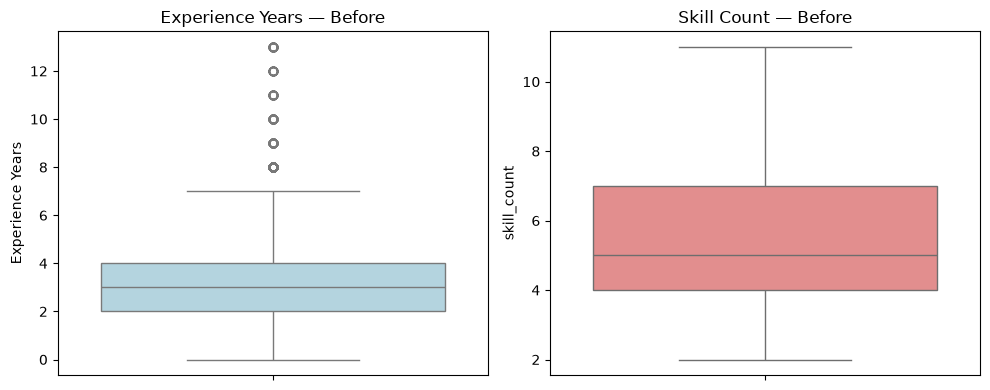

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=resume_df['Experience Years'], ax=axes[0], color='lightblue')
axes[0].set_title('Experience Years — Before')
sns.boxplot(y=resume_df['skill_count'], ax=axes[1], color='lightcoral')
axes[1].set_title('Skill Count — Before')
plt.tight_layout(); plt.savefig('plots/outliers_before.png', dpi=150); plt.show()


In [7]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

outlier_summary = {}
for col in ['Experience Years', 'skill_count']:
    low, high = iqr_bounds(resume_df[col])
    n_out = int(((resume_df[col] < low) | (resume_df[col] > high)).sum())
    outlier_summary[col] = n_out
    resume_df[col] = resume_df[col].clip(lower=low, upper=high).round().astype(int)

print("Outliers capped (IQR):", outlier_summary)


Outliers capped (IQR): {'Experience Years': 395, 'skill_count': 0}


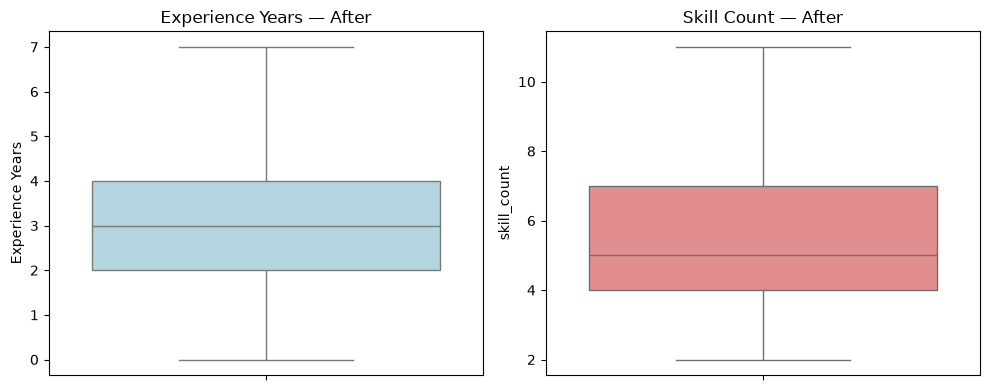

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=resume_df['Experience Years'], ax=axes[0], color='lightblue')
axes[0].set_title('Experience Years — After')
sns.boxplot(y=resume_df['skill_count'], ax=axes[1], color='lightcoral')
axes[1].set_title('Skill Count — After')
plt.tight_layout(); plt.savefig('plots/outliers_after.png', dpi=150); plt.show()


## 4. EDA — Resume Dataset

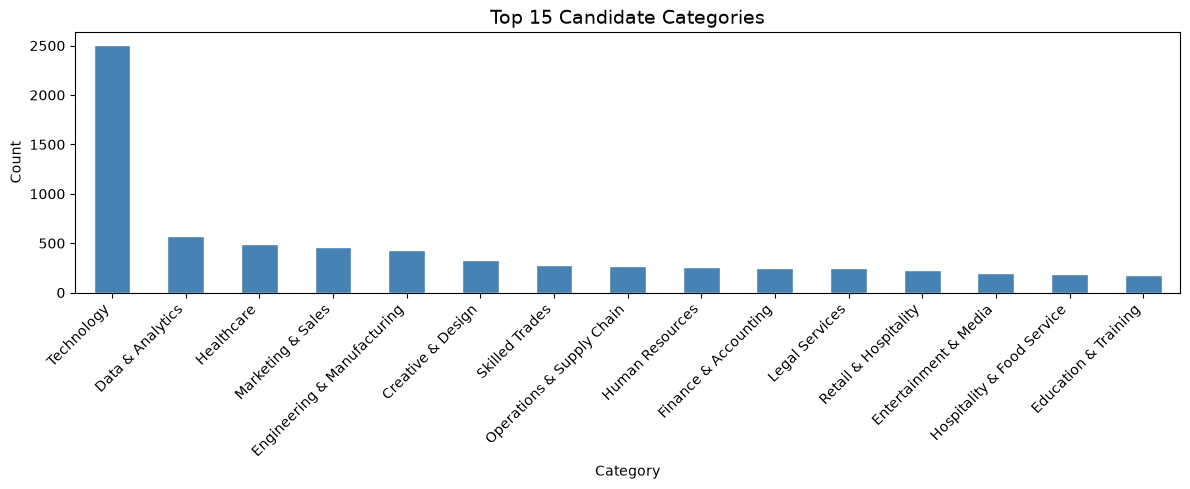

In [9]:
plt.figure(figsize=(12, 5))
resume_df['Category'].value_counts().head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Candidate Categories', fontsize=14)
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('plots/category_distribution.png', dpi=150); plt.show()


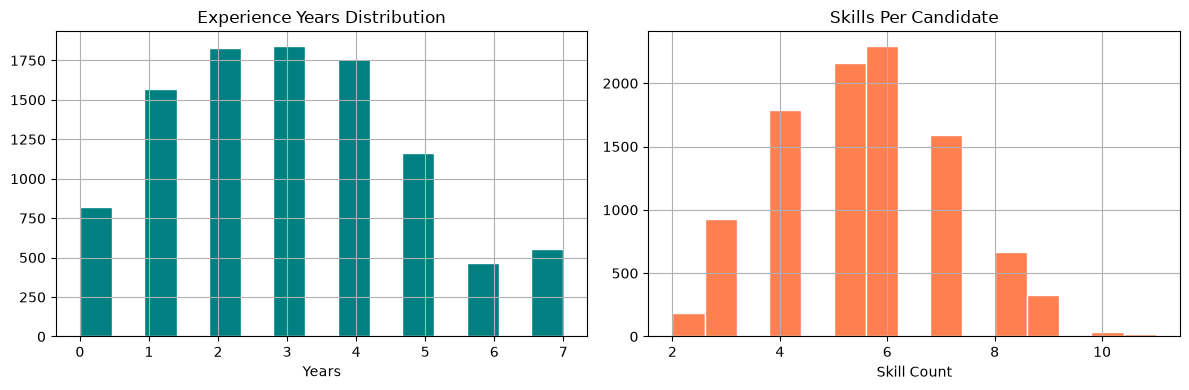

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
resume_df['Experience Years'].hist(bins=15, color='teal', edgecolor='white', ax=axes[0])
axes[0].set_title('Experience Years Distribution'); axes[0].set_xlabel('Years')

resume_df['skill_count'].hist(bins=15, color='coral', edgecolor='white', ax=axes[1])
axes[1].set_title('Skills Per Candidate'); axes[1].set_xlabel('Skill Count')
plt.tight_layout(); plt.savefig('plots/numeric_distributions.png', dpi=150); plt.show()


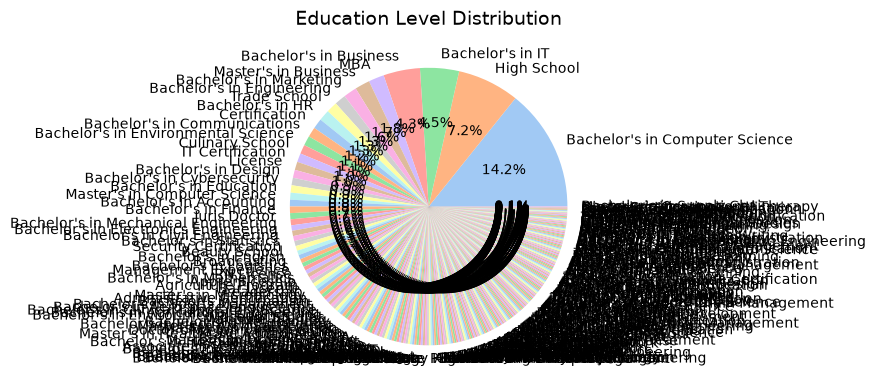

In [11]:
plt.figure(figsize=(7, 4))
edu_counts = resume_df['Education'].value_counts()
plt.pie(edu_counts.values, labels=edu_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'))
plt.title('Education Level Distribution', fontsize=14)
plt.tight_layout(); plt.savefig('plots/education_distribution.png', dpi=150); plt.show()


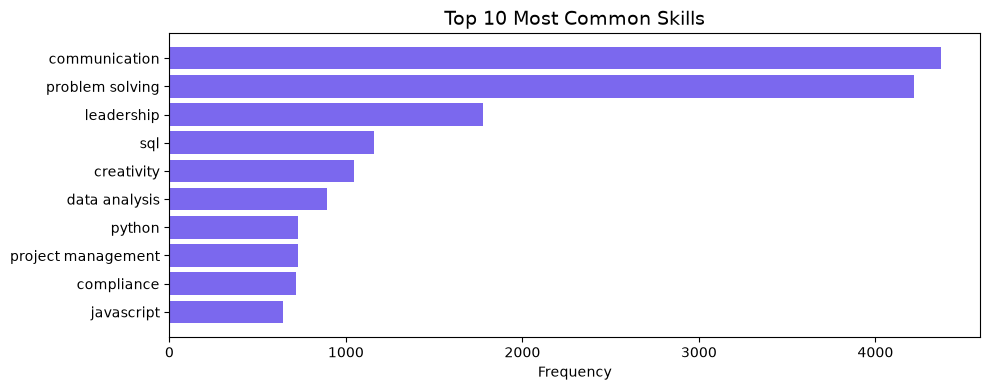

In [12]:
all_skills = [s for sublist in resume_df['extracted_skills'] for s in sublist]
top_skills = Counter(all_skills).most_common(10)
skill_names, skill_counts_vals = zip(*top_skills)

plt.figure(figsize=(10, 4))
plt.barh(skill_names, skill_counts_vals, color='mediumslateblue')
plt.title('Top 10 Most Common Skills', fontsize=14); plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.savefig('plots/top_skills.png', dpi=150); plt.show()


## 5. EDA — Jobs Dataset

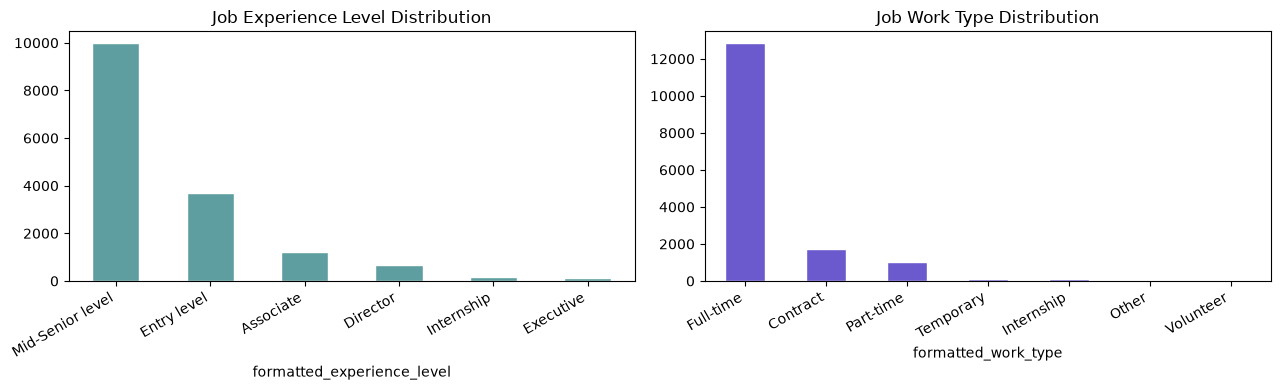

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
jobs_df['formatted_experience_level'].value_counts().plot(
    kind='bar', color='cadetblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Job Experience Level Distribution')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

jobs_df['formatted_work_type'].value_counts().plot(
    kind='bar', color='slateblue', edgecolor='white', ax=axes[1])
axes[1].set_title('Job Work Type Distribution')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout(); plt.savefig('plots/jobs_eda.png', dpi=150); plt.show()


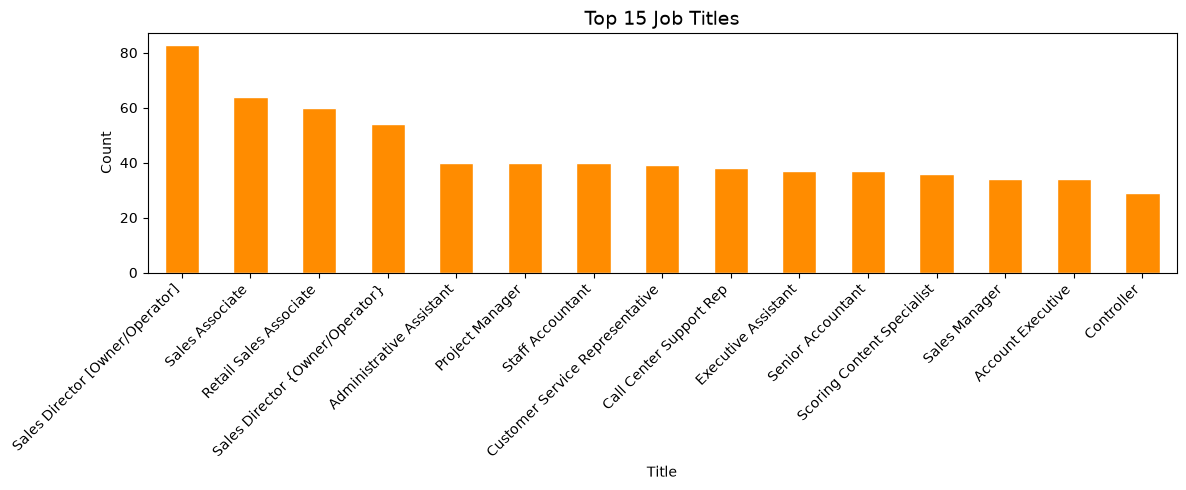

In [14]:
# Top 15 job titles
plt.figure(figsize=(12, 5))
jobs_df['title'].value_counts().head(15).plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Top 15 Job Titles', fontsize=14)
plt.xlabel('Title'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('plots/top_job_titles.png', dpi=150); plt.show()


## 6. Feature Correlation Analysis

In [15]:
known_skills = set(skills_df['Skill Name'].str.lower())
def pct_known(skills):
    if len(skills) == 0: return np.nan
    return sum(s.lower() in known_skills for s in skills) / len(skills)

resume_df['known_skill_ratio'] = resume_df['extracted_skills'].apply(pct_known)
print("Avg % known skills:", round(resume_df['known_skill_ratio'].mean() * 100, 2), "%")


Avg % known skills: 100.0 %


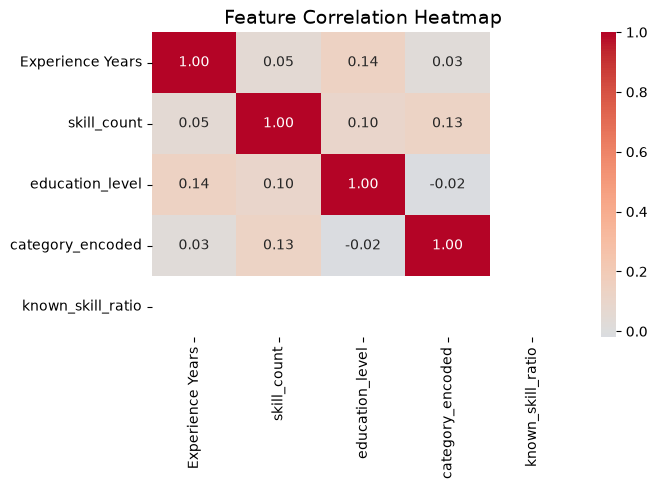

In [16]:
numeric_for_corr = resume_df[['Experience Years', 'skill_count', 'education_level',
                               'category_encoded', 'known_skill_ratio']]
corr = numeric_for_corr.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout(); plt.savefig('plots/correlation_heatmap.png', dpi=150); plt.show()


## 7. Save Processed Data for Next Notebooks

In [17]:
resume_df.to_csv('data/processed_resume.csv', index=False)
jobs_df.to_csv('data/processed_jobs.csv', index=False)
print("Saved: data/processed_resume.csv")
print("Saved: data/processed_jobs.csv")
print("\n✅ 01_EDA.ipynb complete — run 02_Preprocessing_Feature_Engineering.ipynb next.")


Saved: data/processed_resume.csv
Saved: data/processed_jobs.csv

✅ 01_EDA.ipynb complete — run 02_Preprocessing_Feature_Engineering.ipynb next.
